In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.isnull().mean()

RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop(columns=["RowNumber", "CustomerId" , "Surname"] , inplace=True)
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

In [8]:
#Encoding 
df = pd.get_dummies(df, columns=["Geography" , "Gender"], drop_first=True , dtype='int')

In [9]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [10]:
X=df.drop(columns=["Exited"]) 
y=df["Exited"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential

In [13]:
from tensorflow.keras.layers import Dense 
model=Sequential([
    Dense(units=4 , activation='relu' , input_shape=(X.shape[1],)),
    Dense(units=2 , activation='relu' ),
    Dense(units=1, activation='sigmoid')
]) 

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 4)                   │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │              10 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [16]:
history=model.fit(X_train,y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6052 - loss: 1487.7578 - val_accuracy: 0.5312 - val_loss: 732.7578
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4833 - loss: 376.1740 - val_accuracy: 0.3944 - val_loss: 131.9648
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6925 - loss: 80.8631 - val_accuracy: 0.7837 - val_loss: 57.3997
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7814 - loss: 37.6213 - val_accuracy: 0.7831 - val_loss: 25.9347
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7773 - loss: 13.1859 - val_accuracy: 0.7469 - val_loss: 3.7426
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7738 - loss: 3.0840 - val_accuracy: 0.7812 - val_loss: 1.4885
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7731 - loss: 2.1371 - val_accuracy: 0.7831 - val_loss: 1.3833
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7705 - loss: 1.7

In [17]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [18]:
y_pred

array([[0.20353231],
       [0.20353231],
       [0.20353231],
       ...,
       [0.20353231],
       [0.20353231],
       [0.20353231]], shape=(2000, 1), dtype=float32)

In [19]:
y_pred = y_pred.argmax(axis=-1)

In [20]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8035

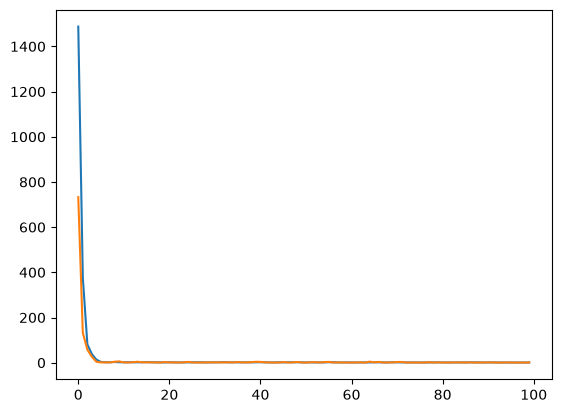

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

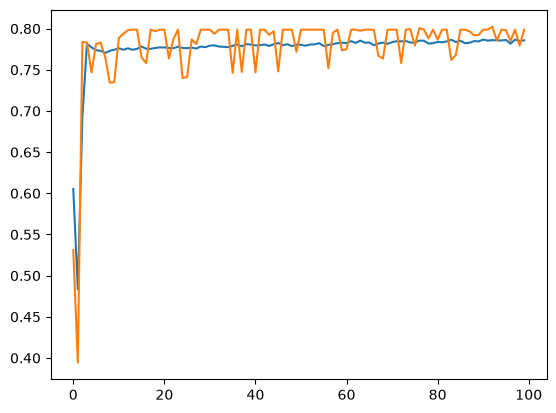

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

### Using Pytorch

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert to Tensor
X_train = torch.FloatTensor(X_train.values)
y_train = torch.FloatTensor(y_train.values).reshape(-1, 1)


# Neural Network
class NeuralNetwork(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(input_size,4),
            nn.ReLU(),

            nn.Linear(4,2),
            nn.ReLU(),

            nn.Linear(2,1),
            nn.Sigmoid()

        )

    def forward(self,x):
        return self.model(x)

# Model
model = NeuralNetwork(X_train.shape[1])

# Loss
criterion = nn.BCELoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Training
epochs = 100

for epoch in range(epochs):

    outputs = model(X_train)

    loss = criterion(outputs,y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    print(f"Epoch {epoch+1}: {loss.item():.4f}")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17532\3627767477.py:7: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train = torch.FloatTensor(y_train.values).reshape(-1, 1)


Epoch 1: 43.5588
Epoch 2: 43.2028
Epoch 3: 43.0832
Epoch 4: 42.8351
Epoch 5: 42.5228
Epoch 6: 42.3008
Epoch 7: 42.0402
Epoch 8: 41.8819
Epoch 9: 41.5489
Epoch 10: 41.2563
Epoch 11: 41.0800
Epoch 12: 40.8671
Epoch 13: 40.7591
Epoch 14: 40.6464
Epoch 15: 40.4421
Epoch 16: 40.2868
Epoch 17: 40.1391
Epoch 18: 40.0492
Epoch 19: 39.9568
Epoch 20: 39.8564
Epoch 21: 39.8077
Epoch 22: 39.6815
Epoch 23: 39.5361
Epoch 24: 39.4913
Epoch 25: 39.3018
Epoch 26: 39.1848
Epoch 27: 39.0882
Epoch 28: 38.9599
Epoch 29: 38.7619
Epoch 30: 38.5917
Epoch 31: 38.5643
Epoch 32: 38.3899
Epoch 33: 38.1855
Epoch 34: 34.5306
Epoch 35: 13.0401
Epoch 36: 14.3726
Epoch 37: 15.6124
Epoch 38: 16.5965
Epoch 39: 17.4367
Epoch 40: 18.1092
Epoch 41: 18.6813
Epoch 42: 19.1001
Epoch 43: 19.4319
Epoch 44: 19.6671
Epoch 45: 19.8375
Epoch 46: 19.9551
Epoch 47: 20.0496
Epoch 48: 20.1273
Epoch 49: 20.1794
Epoch 50: 20.2225
Epoch 51: 20.2607
Epoch 52: 20.2865
Epoch 53: 20.3121
Epoch 54: 20.3344
Epoch 55: 20.3474
Epoch 56: 20.3590
E